In [1]:
import pandas as pd

In [2]:
df1=pd.read_csv('jobs_mongodb.csv')

In [3]:
df=df1.copy()

In [4]:
df.shape

(7269, 42)

In [5]:
df.columns.tolist()

['absolute_url',
 'ai_opt_out_request_url',
 'category',
 'city',
 'company_name',
 'content_clean',
 'contract_time',
 'contract_type',
 'created',
 'created_date',
 'created_time',
 'demographic_data_consent_applies',
 'departments_clean',
 'education',
 'ic_or_mg',
 'id',
 'include_ai_disclaimer',
 'internal_job_id',
 'job_level',
 'job_type',
 'language_clean',
 'latitude',
 'location_clean',
 'longitude',
 'offices_clean',
 'other_market_salary_currency',
 'other_market_salary_max',
 'other_market_salary_min',
 'pay_transparency_max',
 'pay_transparency_min',
 'pay_transparency_unit',
 'region',
 'requisition_id',
 'salary_currency',
 'salary_max',
 'salary_min',
 'standard_role',
 'state',
 'title',
 'updated_at',
 'working_model_clean',
 'source']

In [6]:
df.dtypes

absolute_url                         object
ai_opt_out_request_url               object
category                             object
city                                 object
company_name                         object
content_clean                        object
contract_time                        object
contract_type                        object
created                              object
created_date                         object
created_time                         object
demographic_data_consent_applies    float64
departments_clean                    object
education                            object
ic_or_mg                             object
id                                    int64
include_ai_disclaimer                object
internal_job_id                     float64
job_level                            object
job_type                             object
language_clean                       object
latitude                            float64
location_clean                  

In [7]:
df.duplicated().sum()

0

In [8]:
source_counts=df['source'].value_counts()
source_counts

source
Adzuna        4964
Greenhouse    2305
Name: count, dtype: int64

In [9]:
(df['source'].value_counts(normalize=True)*100).round(2)

source
Adzuna        68.29
Greenhouse    31.71
Name: proportion, dtype: float64

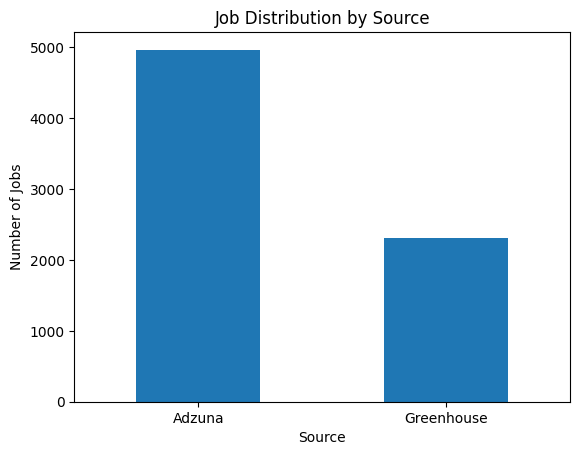

In [10]:
import matplotlib.pyplot as plt
source_counts.plot(kind='bar')
plt.title('Job Distribution by Source')
plt.xlabel('Source')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=0)
plt.show()

In [11]:
missing_value=df.isnull().sum()
print(missing_value[missing_value>0].sort_values(ascending=False))

other_market_salary_min             7219
other_market_salary_max             7219
other_market_salary_currency        7139
education                           7109
pay_transparency_min                7073
pay_transparency_max                7073
pay_transparency_unit               7071
contract_type                       7013
working_model_clean                 6888
region                              6888
job_level                           6888
job_type                            6888
ic_or_mg                            6848
ai_opt_out_request_url              6677
salary_currency                     6667
include_ai_disclaimer               6286
requisition_id                      5567
offices_clean                       4977
internal_job_id                     4977
updated_at                          4964
language_clean                      4964
departments_clean                   4964
demographic_data_consent_applies    4964
salary_min                          4653
latitude        

In [12]:
missing_precentage=(df.isnull().sum()/len(df)*100).sort_values(ascending=False)
print(missing_precentage[missing_precentage>0])

other_market_salary_min             99.312147
other_market_salary_max             99.312147
other_market_salary_currency        98.211583
education                           97.798872
pay_transparency_min                97.303618
pay_transparency_max                97.303618
pay_transparency_unit               97.276104
contract_type                       96.478195
job_level                           94.758564
job_type                            94.758564
working_model_clean                 94.758564
region                              94.758564
ic_or_mg                            94.208282
ai_opt_out_request_url              91.855826
salary_currency                     91.718256
include_ai_disclaimer               86.476819
requisition_id                      76.585500
offices_clean                       68.468840
internal_job_id                     68.468840
language_clean                      68.289999
departments_clean                   68.289999
demographic_data_consent_applies  

In [13]:
missing_by_source = df.groupby('source').apply(lambda x: x.isna().mean() * 100, include_groups=False).round(2)
print(missing_by_source.T)

source                            Adzuna  Greenhouse
absolute_url                        0.00        0.00
ai_opt_out_request_url            100.00       74.32
category                            0.00      100.00
city                               23.27       99.70
company_name                        0.00        0.00
content_clean                       0.00        0.00
contract_time                      21.43      100.00
contract_type                      94.84      100.00
created                             0.00        0.00
created_date                        0.00        0.00
created_time                        0.00        0.00
demographic_data_consent_applies  100.00        0.00
departments_clean                 100.00        0.00
education                         100.00       93.06
ic_or_mg                          100.00       81.74
id                                  0.00        0.00
include_ai_disclaimer             100.00       57.35
internal_job_id                   100.00      

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7269 entries, 0 to 7268
Data columns (total 42 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   absolute_url                      7269 non-null   object 
 1   ai_opt_out_request_url            592 non-null    object 
 2   category                          4964 non-null   object 
 3   city                              3816 non-null   object 
 4   company_name                      7269 non-null   object 
 5   content_clean                     7269 non-null   object 
 6   contract_time                     3900 non-null   object 
 7   contract_type                     256 non-null    object 
 8   created                           7269 non-null   object 
 9   created_date                      7269 non-null   object 
 10  created_time                      7269 non-null   object 
 11  demographic_data_consent_applies  2305 non-null   float64
 12  depart

In [15]:
df['created'] = pd.to_datetime(df['created'], errors='coerce', utc=True)

In [16]:
df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')

In [17]:
df['created_time'] = pd.to_datetime(df['created_time'],format='%H:%M:%S',errors='coerce')

In [18]:
df['updated_at'] = pd.to_datetime(df['updated_at'],errors='coerce',utc=True)

In [19]:
print(df[['created', 'created_date', 'created_time', 'updated_at']].dtypes)

created         datetime64[ns, UTC]
created_date         datetime64[ns]
created_time         datetime64[ns]
updated_at      datetime64[ns, UTC]
dtype: object


# univariate analysis.

In [20]:
df['standard_role'].value_counts(dropna=False)

standard_role
NaN                              2305
Frontend Developer                393
DevOps Engineer                   393
Python Developer                  391
Full Stack Developer              388
Java Developer                    384
Backend Developer                 383
Data Analyst                      369
Business Analyst                  359
Cloud Engineer                    341
Data Scientist                    338
Software Engineer                 311
Machine Learning Engineer         288
Other                             277
Cyber Security                    226
Data Engineer                      31
Academic                           22
Sales                              17
AI Engineer                        13
Project Manager                    11
Software Development Engineer       9
Platform Engineer                   8
Technical Lead                      6
Software Architect                  2
Engineering Manager                 2
AI Architect                        

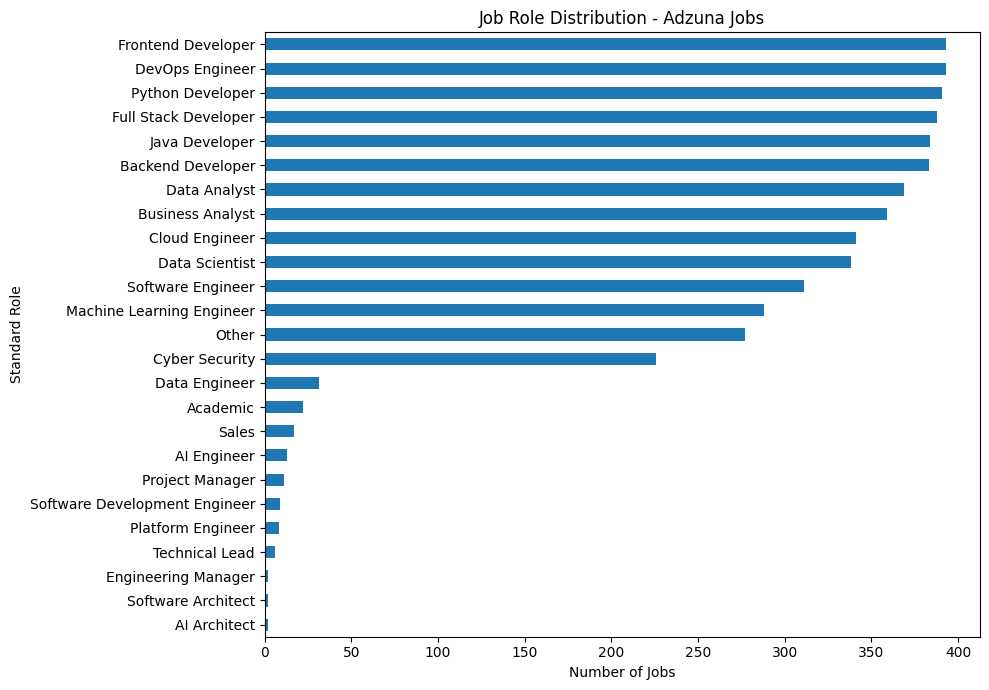

In [21]:
role_counts = df['standard_role'].dropna().value_counts()

plt.figure(figsize=(10, 7))

role_counts.sort_values().plot(kind='barh')

plt.title('Job Role Distribution - Adzuna Jobs')
plt.xlabel('Number of Jobs')
plt.ylabel('Standard Role')

plt.tight_layout()
plt.show()

In [22]:
df['title'].value_counts().head(20)

title
frontend developer                      391
python developer                        381
backend developer                       380
java developer                          373
devops engineer                         363
full stack developer                    357
business analyst                        324
data scientist                          254
data analyst                            200
software engineer                       148
machine learning engineer                69
cloud platform engineer                  49
cloud engineer                           40
senior data analyst                      38
senior machine learning engineer         38
senior cloud engineer                    21
Enterprise Account Executive, Growth     21
cloud migration engineer                 17
full-stack developer                     15
Strategic Account Executive              14
Name: count, dtype: int64

In [23]:
df['title'].nunique()

2913

In [24]:
print('top 20 job title',df['title'].value_counts().head(20))

top 20 job title title
frontend developer                      391
python developer                        381
backend developer                       380
java developer                          373
devops engineer                         363
full stack developer                    357
business analyst                        324
data scientist                          254
data analyst                            200
software engineer                       148
machine learning engineer                69
cloud platform engineer                  49
cloud engineer                           40
senior data analyst                      38
senior machine learning engineer         38
senior cloud engineer                    21
Enterprise Account Executive, Growth     21
cloud migration engineer                 17
full-stack developer                     15
Strategic Account Executive              14
Name: count, dtype: int64


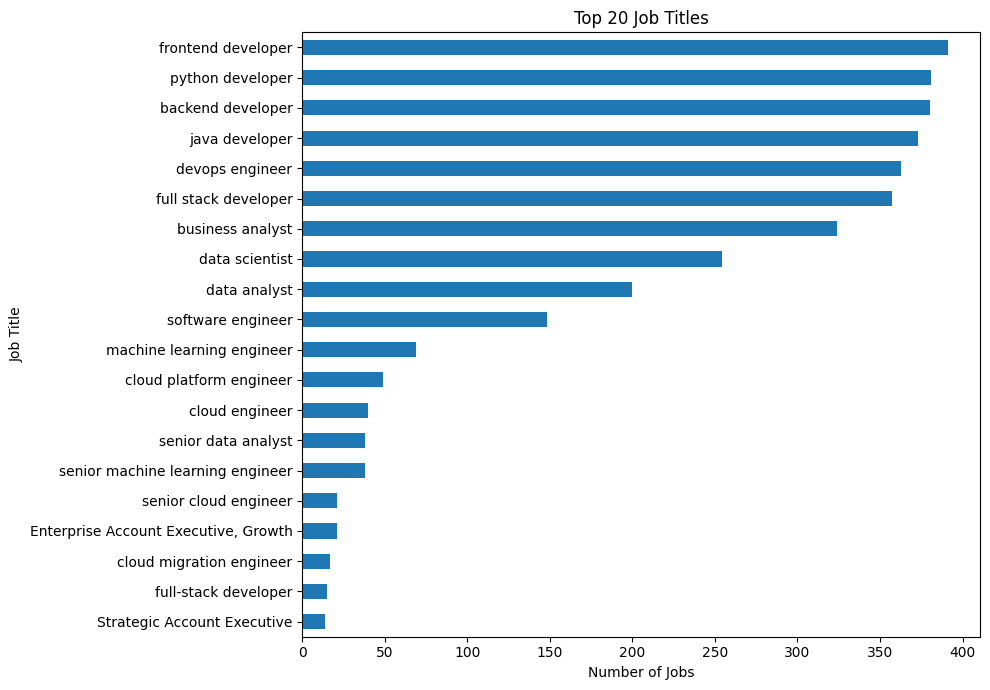

In [25]:
top_title=df['title'].value_counts().head(20)
plt.figure(figsize=(10,7))
top_title.sort_values().plot(kind='barh')
plt.title('Top 20 Job Titles')
plt.xlabel('Number of Jobs')
plt.ylabel('Job Title')

plt.tight_layout()
plt.show()

In [26]:
df['company_name'].nunique()

2505

In [27]:
df['company_name'].value_counts()

company_name
Stripe                                524
Datadog                               421
MongoDB                               381
Brex                                  266
Figma                                 169
                                     ... 
Zapro                                   1
Turbolab Technologies                   1
encircle.io                             1
Plaza                                   1
PeopleProsper Technologies Pvt Ltd      1
Name: count, Length: 2505, dtype: int64

In [28]:
df['company_name'].value_counts().head(20)

company_name
Stripe                    524
Datadog                   421
MongoDB                   381
Brex                      266
Figma                     169
Flexport                  148
Asana                     146
Accenture                 116
Gusto, Inc.                78
Kyndryl                    71
Vercel                     67
Qrata                      66
Checkr                     60
Jobdost                    56
Capco                      50
Wissen Technology          49
Unknown                    46
Warner Bros. Discovery     45
eBay                       45
Reckitt                    40
Name: count, dtype: int64

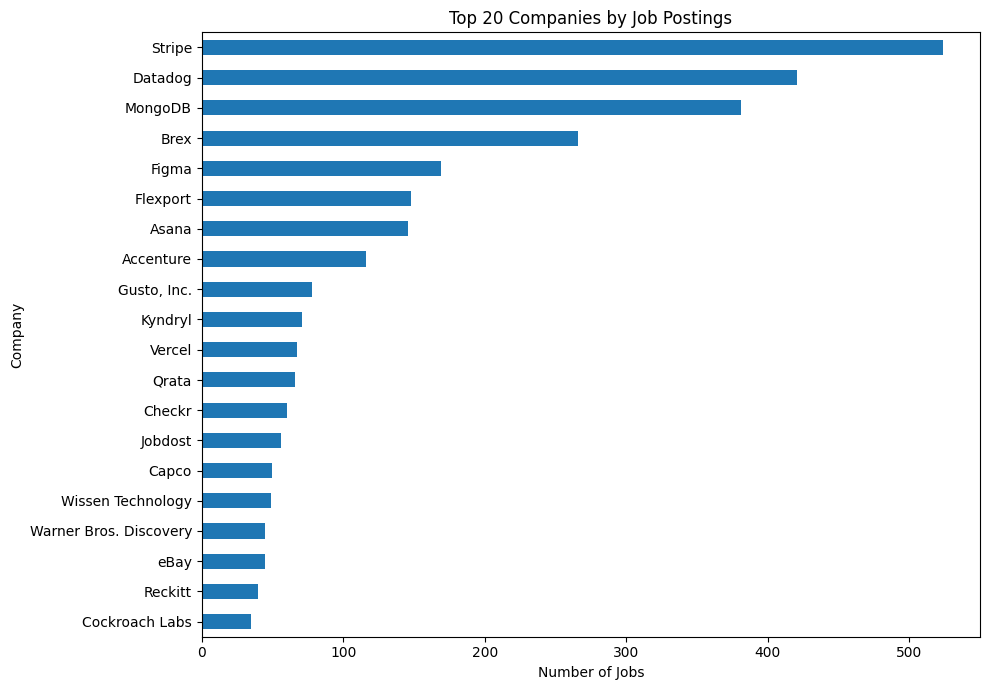

In [29]:
company_count=(df.loc[df['company_name'].ne('Unknown'),'company_name'].value_counts())
top_company=company_count.head(20)
plt.figure(figsize=(10,7))
top_company.sort_values().plot(kind='barh')
plt.title('Top 20 Companies by Job Postings')
plt.xlabel('Number of Jobs')
plt.ylabel('Company')

plt.tight_layout()
plt.show()

In [30]:
df['city'].nunique()

70

In [31]:
df['city'].value_counts().head(20)

city
Bangalore             1335
Hyderabad              442
Mumbai                 422
Pune                   404
Chennai                293
Delhi                  195
Noida                  171
Ahmedabad               80
Gurgaon                 67
Navi Mumbai             47
Kolkata                 45
Jaipur                  40
Indore                  39
Kochi                   24
Coimbatore              23
Mohali                  16
Surat                   15
Thiruvananthapuram      14
Vadodara                13
Thane                   12
Name: count, dtype: int64

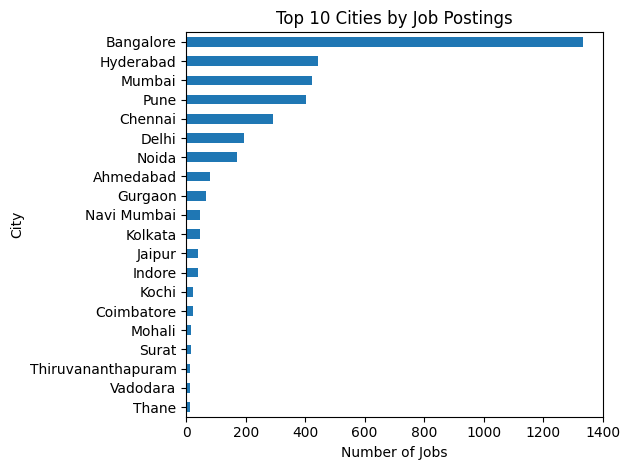

In [32]:
top_city=df['city'].value_counts().head(20)
top_city.sort_values().plot(kind='barh')
plt.title('Top 10 Cities by Job Postings')
plt.xlabel('Number of Jobs')
plt.ylabel('City')

plt.tight_layout()
plt.show()

In [33]:
df['state'].value_counts()

state
Karnataka            1339
Maharashtra           905
Telangana             446
Tamil Nadu            327
Delhi                 195
Uttar Pradesh         189
Gujarat               122
Haryana                72
Rajasthan              52
West Bengal            45
Kerala                 42
Madhya Pradesh         42
Punjab                 19
Chandigarh             12
Uttarakhand             8
Andhra Pradesh          5
Ontario                 5
Goa                     4
Odisha                  4
Jharkhand               2
Chhattisgarh            1
Bihar                   1
Jammu and Kashmir       1
São Paulo               1
Illinois                1
Name: count, dtype: int64

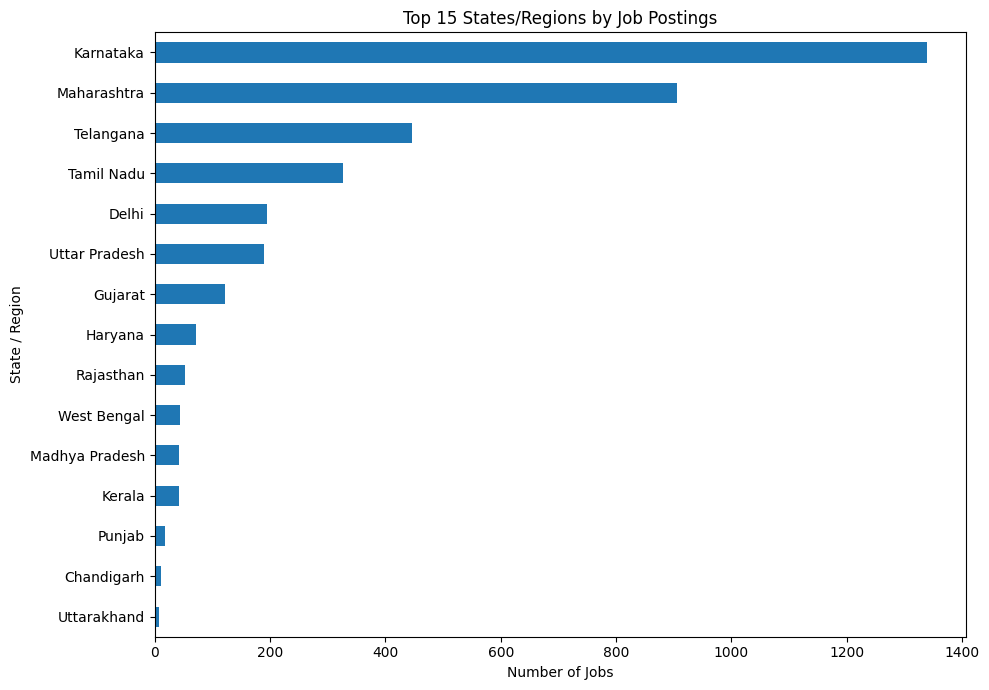

In [34]:
state_counts = df['state'].value_counts()

top_states = state_counts.head(15)

plt.figure(figsize=(10, 7))

top_states.sort_values().plot(kind='barh')

plt.title('Top 15 States/Regions by Job Postings')
plt.xlabel('Number of Jobs')
plt.ylabel('State / Region')

plt.tight_layout()
plt.show()

In [35]:
df['salary_currency'].notna().sum()

602

In [36]:
df['salary_min'].notna().sum()

2616

In [37]:
df['salary_max'].notna().sum()

2915

In [38]:
df['salary_currency'].value_counts(dropna=False)

salary_currency
NaN    6667
USD     468
EUR      48
CAD      25
GBP      18
INR      13
AUD       6
SGD       5
BRL       4
ILS       3
KRW       3
MYR       3
MXN       2
TWD       1
HKD       1
SEK       1
PLN       1
Name: count, dtype: int64

In [39]:
df['salary_min'].describe()

count    2.616000e+03
mean     6.406804e+05
std      5.693474e+05
min      3.000000e+03
25%      2.080000e+05
50%      5.000000e+05
75%      9.000000e+05
max      4.500000e+06
Name: salary_min, dtype: float64

In [40]:
df['salary_max'].describe()

count    2.915000e+03
mean     1.315851e+06
std      1.055261e+06
min      2.000000e+04
25%      5.000000e+05
50%      1.200000e+06
75%      1.800000e+06
max      9.000000e+06
Name: salary_max, dtype: float64

In [41]:
# Salary distributions were analyzed separately by currency 
# because salary values are reported in multiple currencies and were not converted.

In [42]:
salary_by_currency=(df[df['salary_currency'].notna()]
                    .groupby('salary_currency')[['salary_min','salary_max']]
                    .agg(['count', 'min', 'median', 'mean', 'max'])
                    .round(2))

print(salary_by_currency)

                salary_min                                           \
                     count       min    median       mean       max   
salary_currency                                                       
AUD                      3  280000.0  388000.0  352000.00  388000.0   
BRL                      0       NaN       NaN        NaN       NaN   
CAD                     20   90000.0  135200.0  144710.00  244100.0   
EUR                     19   56560.0  100000.0  102250.53  157000.0   
GBP                     14   75300.0  108400.0  112585.71  200000.0   
HKD                      0       NaN       NaN        NaN       NaN   
ILS                      0       NaN       NaN        NaN       NaN   
INR                      0       NaN       NaN        NaN       NaN   
KRW                      0       NaN       NaN        NaN       NaN   
MXN                      0       NaN       NaN        NaN       NaN   
MYR                      0       NaN       NaN        NaN       NaN   
PLN   

In [43]:
usd_salary=df[df['salary_currency']=='USD']
print(len(usd_salary))

468


In [44]:
usd_salary['salary_min'].describe()

count       468.000000
mean     173020.393590
std       56723.955656
min       50000.000000
25%      134200.000000
50%      163700.000000
75%      210925.000000
max      340000.000000
Name: salary_min, dtype: float64

In [45]:
usd_salary['salary_max'].describe()

count       468.000000
mean     240225.318803
std       82013.302468
min       50000.000000
25%      184750.000000
50%      240000.000000
75%      297750.000000
max      563600.000000
Name: salary_max, dtype: float64

In [46]:
import seaborn as sns

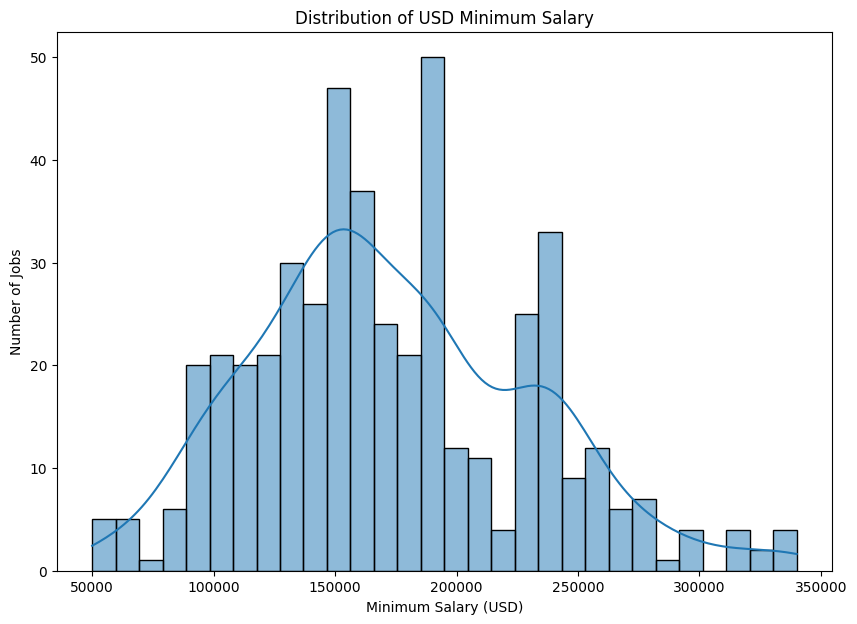

In [47]:
usd_salary=df[df['salary_currency']=='USD']
plt.figure(figsize=(10,7))
sns.histplot(usd_salary['salary_min'].dropna(),bins=30,kde=True)
plt.title('Distribution of USD Minimum Salary')
plt.xlabel('Minimum Salary (USD)')
plt.ylabel('Number of Jobs')

plt.show()

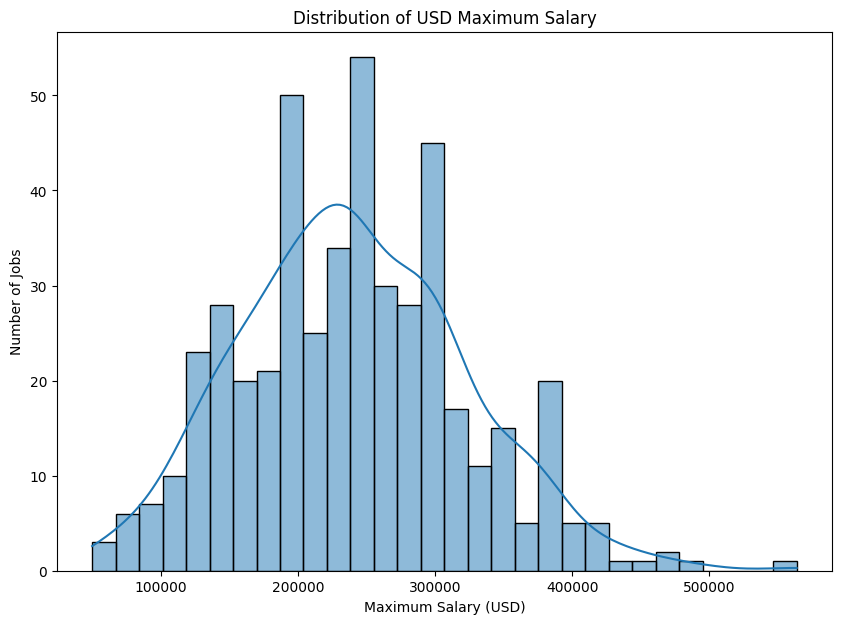

In [48]:
usd_salary=df[df['salary_currency']=='USD']
plt.figure(figsize=(10,7))
sns.histplot(usd_salary['salary_max'].dropna(),bins=30,kde=True)
plt.title('Distribution of USD Maximum Salary')
plt.xlabel('Maximum Salary (USD)')
plt.ylabel('Number of Jobs')

plt.show()

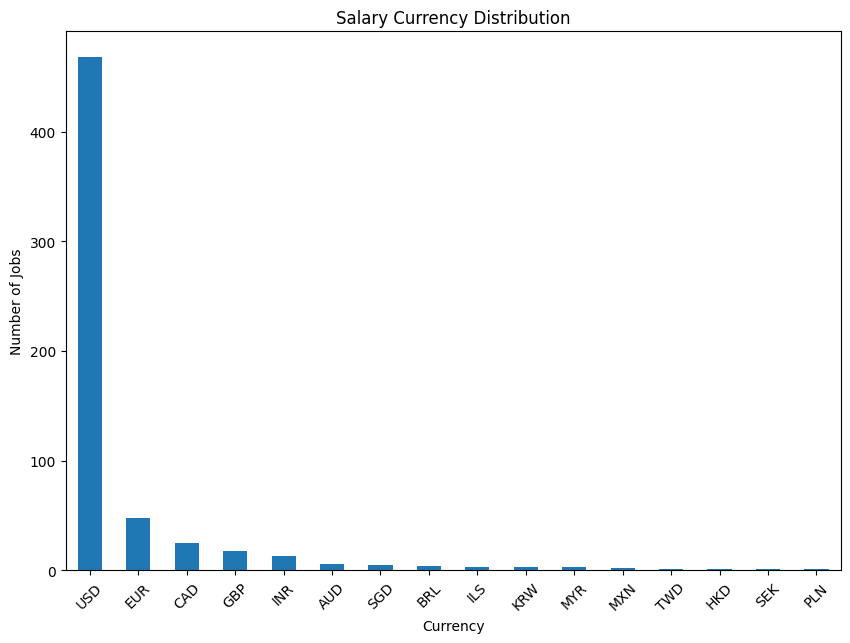

In [49]:
currency_count=df['salary_currency'].value_counts()
plt.figure(figsize=(10,7))
currency_count.plot(kind='bar')
plt.title('Salary Currency Distribution')
plt.xlabel('Currency')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45)

plt.show()

In [50]:
df['education'].value_counts(dropna=False)

education
NaN                                                                                                                                                                                                                  7109
education_optional                                                                                                                                                                                                     43
education_required                                                                                                                                                                                                      9
Bachelor’s or Master’s degree in Computer Science, Engineering, or a related field                                                                                                                                      8
PhD in a scientific field or equivalent experience                                                                    

In [51]:
education_counts = df['education'].dropna().value_counts()
print(df['education'].nunique())
print(education_counts)

72
education
education_optional                                                                                                                                                  43
education_required                                                                                                                                                   9
Bachelor’s or Master’s degree in Computer Science, Engineering, or a related field                                                                                   8
PhD in a scientific field or equivalent experience                                                                                                                   6
PhD in a Computer Science, Engineering or related scientific field or equivalent experience                                                                          4
                                                                                                                                                        

In [52]:
def education_category(x):
    if pd.isna(x):
        return pd.NA
    
    x_lower = x.lower()

    if 'phd' in x_lower:
        return 'PhD'
    elif 'master' in x_lower or 'mba' in x_lower:
        return "Master's"
    elif 'bachelor' in x_lower or 'ba/' in x_lower or 'bs/' in x_lower:
        return "Bachelor's"
    elif 'optional' in x_lower:
        return 'Optional'
    elif 'required' in x_lower:
        return 'Required'
    else:
        return 'Other'


In [53]:
df['education_category'] = df['education'].apply(education_category)

print(df['education_category'].value_counts(dropna=False))

education_category
<NA>          7109
Bachelor's      44
Optional        43
Master's        28
PhD             28
Required         9
Other            8
Name: count, dtype: int64


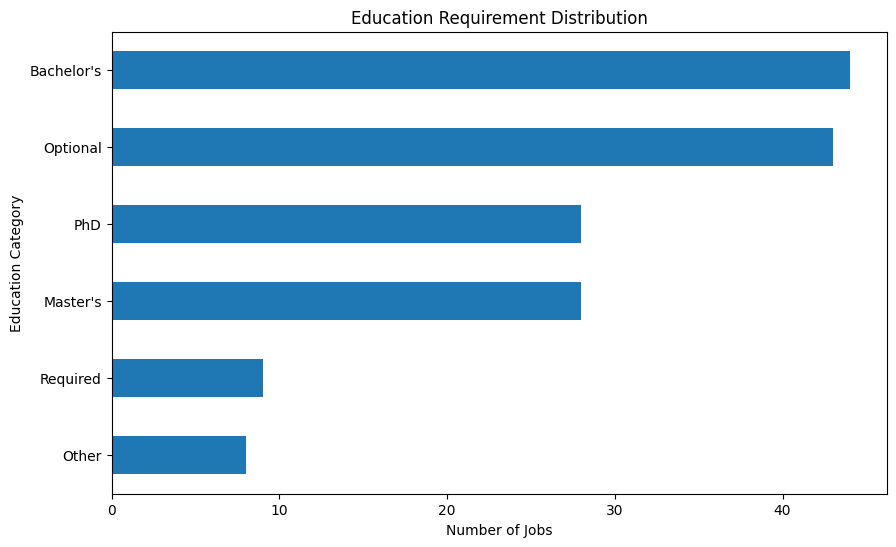

In [54]:
education_counts = (df['education_category'].dropna().value_counts())
plt.figure(figsize=(10, 6))
education_counts.sort_values().plot(kind='barh')

plt.title('Education Requirement Distribution')
plt.xlabel('Number of Jobs')
plt.ylabel('Education Category')

plt.show()

In [55]:
df['working_model_clean'].value_counts(dropna=False)

working_model_clean
NaN                                  6888
Flexible                              294
In Office                              36
Customer Facing Remote                 19
In Office, Flexible, Fully Remote      15
Fully Remote                           12
In Office, Flexible                     4
Flexible, Customer Facing Remote        1
Name: count, dtype: int64

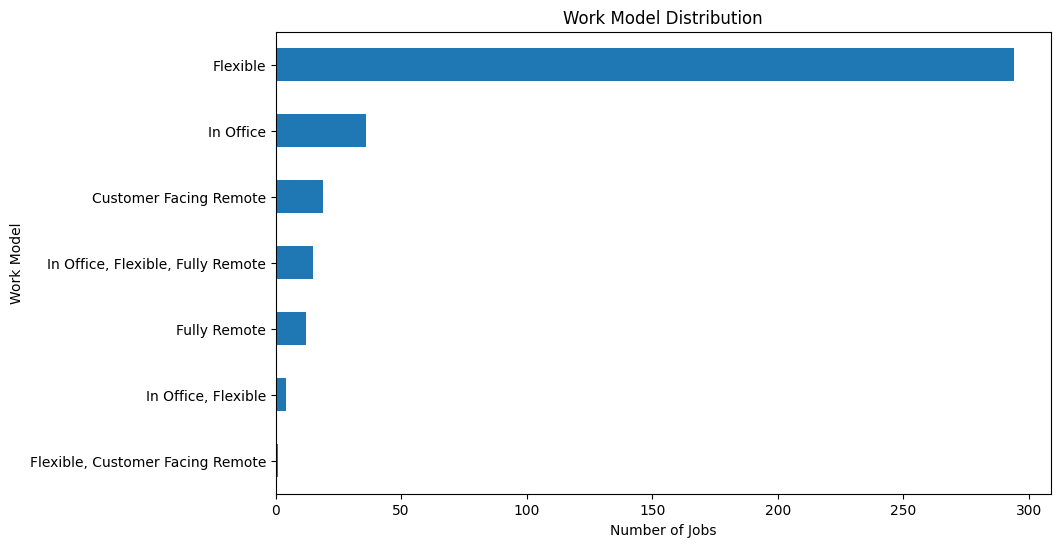

In [56]:
work_model_counts = ( df['working_model_clean'].dropna().value_counts())
plt.figure(figsize=(10, 6))
work_model_counts.sort_values().plot(kind='barh')

plt.title('Work Model Distribution')
plt.xlabel('Number of Jobs')
plt.ylabel('Work Model')

plt.show()

In [57]:
df['job_level'].value_counts(dropna=False)

job_level
NaN                  6888
Professional - IC     202
IC - Professional     123
People Manager         26
Senior Manager         11
Director                9
Manager                 5
Senior Director         3
Support                 1
Vice President          1
Name: count, dtype: int64

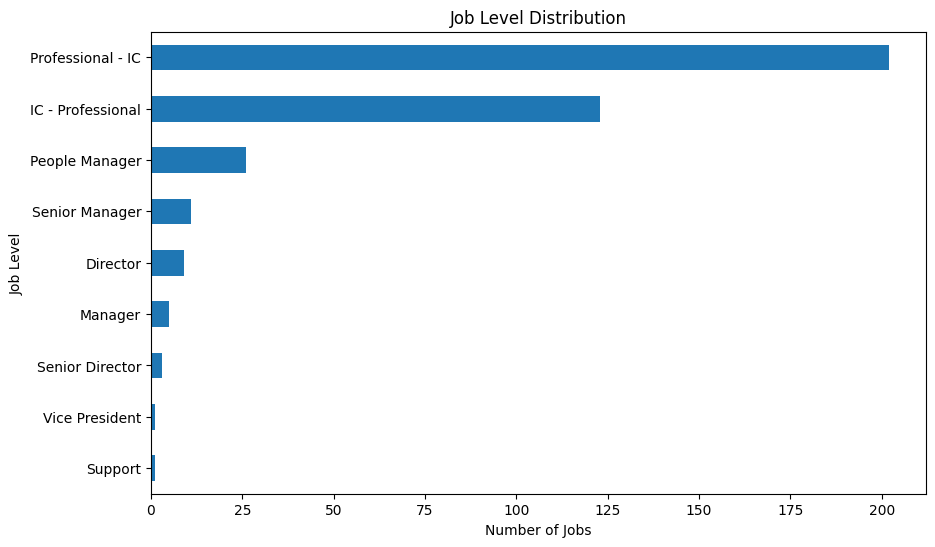

In [58]:
job_level_counts = ( df['job_level'].dropna().value_counts())
plt.figure(figsize=(10, 6))
job_level_counts.sort_values().plot(kind='barh')

plt.title('Job Level Distribution')
plt.xlabel('Number of Jobs')
plt.ylabel('Job Level')

plt.show()

In [59]:
df['created_date'].min()

Timestamp('2019-04-17 00:00:00')

In [60]:
df['created_date'].max()

Timestamp('2026-07-14 00:00:00')

In [61]:
df['created_date'].value_counts().sort_index()

created_date
2019-04-17      1
2019-05-16      1
2019-05-17     30
2019-05-19      1
2019-05-24     17
             ... 
2026-07-10    102
2026-07-11     78
2026-07-12     42
2026-07-13     77
2026-07-14     22
Name: count, Length: 1339, dtype: int64

In [62]:
monthly_postings = (df.dropna(subset=['created_date'])
      .set_index('created_date')
      .resample('ME')
      .size())

print(monthly_postings)

created_date
2019-04-30       1
2019-05-31      51
2019-06-30     161
2019-07-31       4
2019-08-31       7
              ... 
2026-03-31     283
2026-04-30     405
2026-05-31     806
2026-06-30    1249
2026-07-31    1251
Freq: ME, Length: 88, dtype: int64


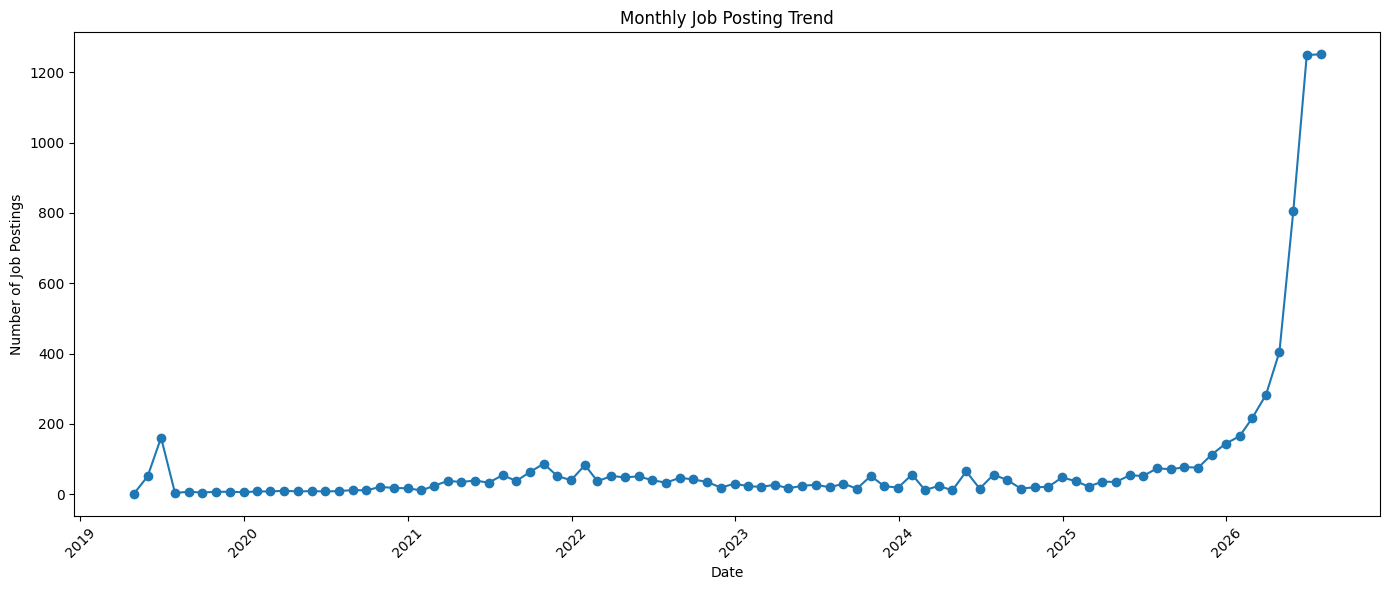

In [63]:
plt.figure(figsize=(14, 6))

plt.plot( monthly_postings.index, monthly_postings.values,marker='o')

plt.title('Monthly Job Posting Trend')
plt.xlabel('Date')
plt.ylabel('Number of Job Postings')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Bivariate

In [66]:
top_titles = df['title'].value_counts().head(15)

print(top_titles)

title
frontend developer                  391
python developer                    381
backend developer                   380
java developer                      373
devops engineer                     363
full stack developer                357
business analyst                    324
data scientist                      254
data analyst                        200
software engineer                   148
machine learning engineer            69
cloud platform engineer              49
cloud engineer                       40
senior data analyst                  38
senior machine learning engineer     38
Name: count, dtype: int64


In [67]:
top_15_titles = df['title'].value_counts().head(15).index

source_title = pd.crosstab( df[df['title'].isin(top_15_titles)]['title'],
    df[df['title'].isin(top_15_titles)]['source'])

print(source_title)

source                            Adzuna
title                                   
backend developer                    380
business analyst                     324
cloud engineer                        40
cloud platform engineer               49
data analyst                         200
data scientist                       254
devops engineer                      363
frontend developer                   391
full stack developer                 357
java developer                       373
machine learning engineer             69
python developer                     381
senior data analyst                   38
senior machine learning engineer      38
software engineer                    148


In [68]:
salary_source = (df.groupby('source')[['salary_min', 'salary_max']].count())
print(salary_source)

            salary_min  salary_max
source                            
Adzuna            2068        2367
Greenhouse         548         548


In [69]:
salary_source_median = ( df.groupby('source')[['salary_min', 'salary_max']].median())
print(salary_source_median)

            salary_min  salary_max
source                            
Adzuna        600000.0   1400000.0
Greenhouse    162000.0    235600.0


In [70]:
usd_source = (df[df['salary_currency'] == 'USD']
        .groupby('source')[['salary_min', 'salary_max']]
        .agg(['count', 'median', 'mean'])
        .round(2))

print(usd_source)

           salary_min                      salary_max                     
                count    median       mean      count    median       mean
source                                                                    
Greenhouse        468  163700.0  173020.39        468  240000.0  240225.32


In [71]:
role_salary = ( df[df['standard_role'].notna()]
     .groupby('standard_role')[['salary_min', 'salary_max']]
     .agg(['count', 'median'])
     .round(2))
print(role_salary)

                              salary_min            salary_max           
                                   count     median      count     median
standard_role                                                            
AI Architect                           0        NaN          0        NaN
AI Engineer                            0        NaN          0        NaN
Academic                               0        NaN          0        NaN
Backend Developer                    295   600000.0        343  1500000.0
Business Analyst                     120   500000.0        146  1000000.0
Cloud Engineer                        46   600000.0         50  1400000.0
Cyber Security                        26   850000.0         27  1500000.0
Data Analyst                          79   500000.0         95  1000000.0
Data Engineer                          5  1200000.0          5  2400000.0
Data Scientist                       137   800000.0        146  2000000.0
DevOps Engineer                      1

In [72]:
role_salary_count = (df[df['standard_role'].notna()]
    .groupby('standard_role')[['salary_min', 'salary_max']]
    .count()
    .sort_values('salary_max', ascending=False))

print(role_salary_count)

                               salary_min  salary_max
standard_role                                        
Frontend Developer                    289         356
Backend Developer                     295         343
Python Developer                      262         302
Full Stack Developer                  269         276
Java Developer                        229         265
DevOps Engineer                       180         213
Data Scientist                        137         146
Business Analyst                      120         146
Data Analyst                           79          95
Software Engineer                      62          64
Machine Learning Engineer              53          61
Cloud Engineer                         46          50
Cyber Security                         26          27
Other                                  15          16
Data Engineer                           5           5
Sales                                   1           2
Software Development Enginee

<Figure size 1200x900 with 0 Axes>

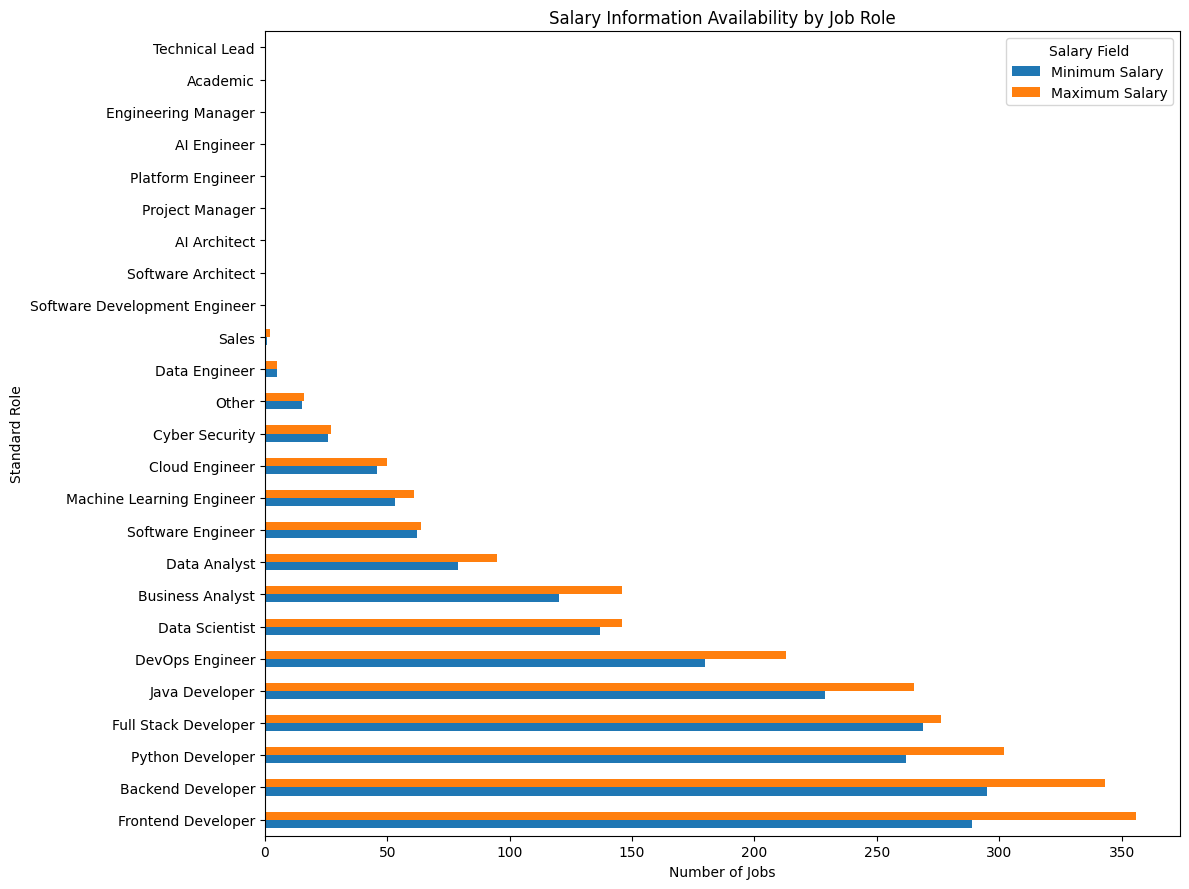

In [73]:
plt.figure(figsize=(12, 9))

role_salary_count.plot(
    kind='barh',
    figsize=(12, 9))

plt.title('Salary Information Availability by Job Role')
plt.xlabel('Number of Jobs')
plt.ylabel('Standard Role')

plt.legend(title='Salary Field',
    labels=['Minimum Salary', 'Maximum Salary'])

plt.tight_layout()
plt.show()

In [74]:
level_salary_count = (
    df[df['job_level'].notna()]
    .groupby('job_level')[['salary_min', 'salary_max']]
    .count()
    .sort_values('salary_max', ascending=False)
)

print(level_salary_count)

                   salary_min  salary_max
job_level                                
Professional - IC          53          53
IC - Professional          30          30
People Manager              6           6
Senior Manager              5           5
Senior Director             2           2
Director                    0           0
Manager                     0           0
Support                     0           0
Vice President              0           0


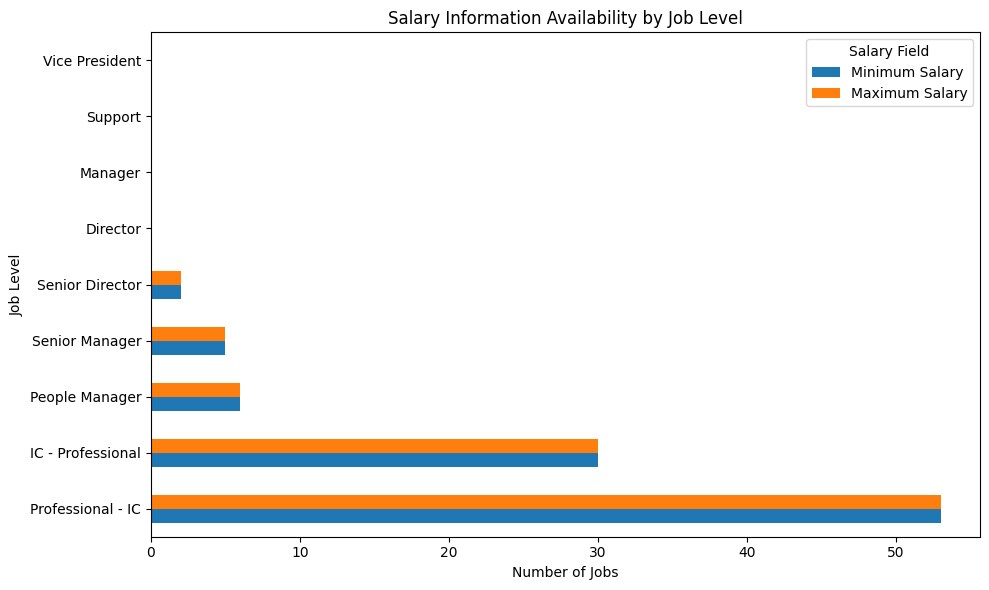

In [75]:
level_salary_count = (df[df['job_level'].notna()]
    .groupby('job_level')[['salary_min', 'salary_max']]
    .count()
    .sort_values('salary_max', ascending=False))

level_salary_count.plot(kind='barh',figsize=(10, 6))

plt.title('Salary Information Availability by Job Level')
plt.xlabel('Number of Jobs')
plt.ylabel('Job Level')
plt.legend(title='Salary Field',labels=['Minimum Salary', 'Maximum Salary'])
plt.tight_layout()
plt.show()

In [76]:
location_salary = (df[df['city'].notna() & df['salary_max'].notna()]
    .groupby('city')
    .agg(job_count=('salary_max', 'count'),
        median_salary=('salary_max', 'median'))
    .sort_values('job_count', ascending=False)
)

location_salary.head(15)

,job_count,median_salary
city,,
Bangalore,656,1500000.0
Mumbai,251,1200000.0
Pune,195,1500000.0
Delhi,153,1200000.0
Hyderabad,149,1500000.0
Chennai,136,1500000.0
Noida,77,1000000.0
Ahmedabad,45,800000.0
Jaipur,34,850000.0


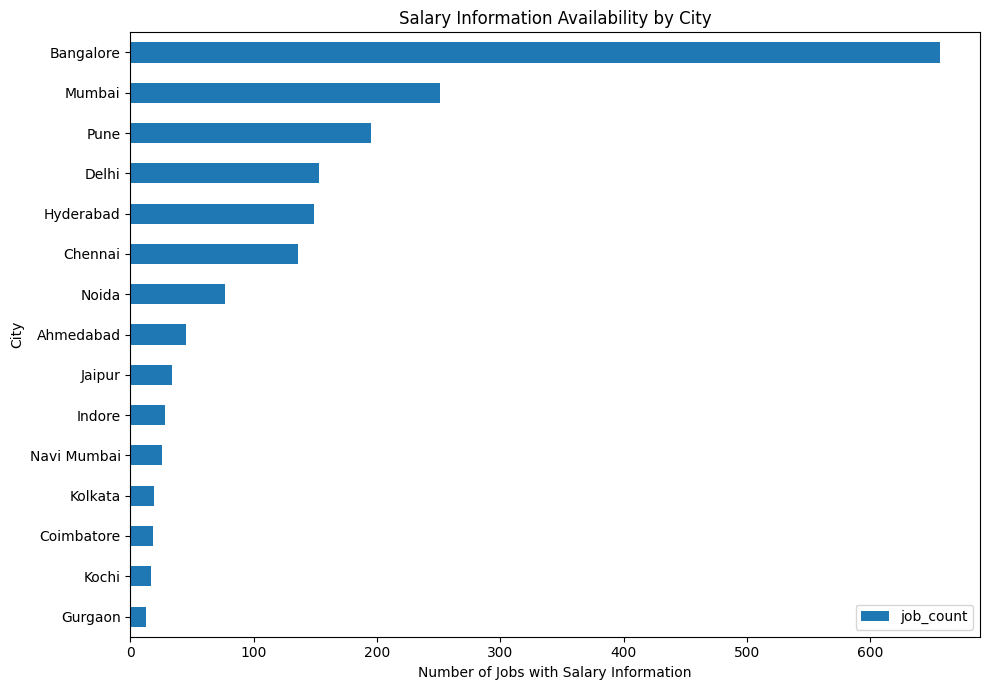

In [77]:
location_salary_top = (
    df[df['city'].notna() & df['salary_max'].notna()]
    .groupby('city')
    .agg(job_count=('salary_max', 'count'))
    .sort_values('job_count', ascending=False)
    .head(15))

location_salary_top.plot(kind='barh',figsize=(10, 7))

plt.title('Salary Information Availability by City')
plt.xlabel('Number of Jobs with Salary Information')
plt.ylabel('City')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [78]:
source_work_model = pd.crosstab(df['working_model_clean'],df['source'])
source_work_model

source,Greenhouse
working_model_clean,
Customer Facing Remote,19
Flexible,294
"Flexible, Customer Facing Remote",1
Fully Remote,12
In Office,36
"In Office, Flexible",4
"In Office, Flexible, Fully Remote",15


In [85]:
level_work_model = pd.crosstab( df['job_level_clean'],df['working_model_clean'])
level_work_model

working_model_clean,Customer Facing Remote,Flexible,"Flexible, Customer Facing Remote",Fully Remote,In Office,"In Office, Flexible","In Office, Flexible, Fully Remote"
job_level_clean,,,,,,,
Director,0,8,0,1,0,0,0
Manager,0,4,0,1,0,0,0
People Manager,0,25,0,0,1,0,0
Professional - IC,19,242,1,10,35,4,14
Senior Director,0,3,0,0,0,0,0
Senior Manager,0,11,0,0,0,0,0
Support,0,1,0,0,0,0,0
Vice President,0,0,0,0,0,0,1


In [82]:
df[df['job_level'].isin(['IC - Professional', 'Professional - IC'])][
    ['job_level', 'title', 'company_name']].head(20)

,job_level,title,company_name
5657,IC - Professional,Account Development Representative,MongoDB
5658,IC - Professional,Account Development Representative,MongoDB
5659,IC - Professional,"Account Development Representative, Arabic Spe...",MongoDB
5660,IC - Professional,Account Development Representative - English S...,MongoDB
5661,IC - Professional,"Account Development Representative, French Spe...",MongoDB
5662,IC - Professional,"Account Development Representative, German Spe...",MongoDB
5663,IC - Professional,"Account Development Representative, Hebrew Spe...",MongoDB
5664,IC - Professional,"Account Development Representative, Spanish Sp...",MongoDB
5665,IC - Professional,"Account Executive, Acquisition",MongoDB
5666,IC - Professional,"Account Executive, Acquisition/Growth",MongoDB


In [83]:
df['job_level_clean'] = df['job_level'].replace({'IC - Professional': 'Professional - IC'})

In [84]:
df['job_level_clean'].value_counts(dropna=False)

job_level_clean
NaN                  6888
Professional - IC     325
People Manager         26
Senior Manager         11
Director                9
Manager                 5
Senior Director         3
Support                 1
Vice President          1
Name: count, dtype: int64

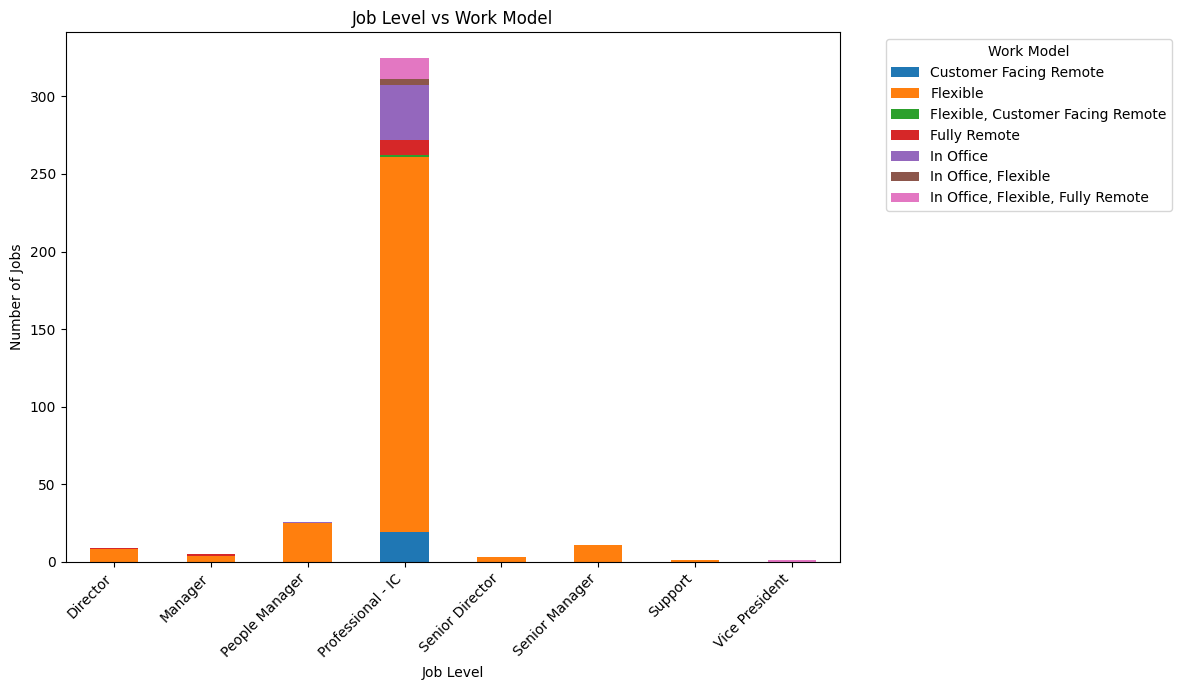

In [86]:
level_work_model.plot(kind='bar',stacked=True,figsize=(12, 7))

plt.title('Job Level vs Work Model')
plt.xlabel('Job Level')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45, ha='right')
plt.legend(
    title='Work Model',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.tight_layout()
plt.show()

# Multivariate EDA

In [87]:
role_city_salary = (df[df['standard_role'].notna() &df['city'].notna() &df['salary_max'].notna()]
    .groupby(['standard_role', 'city'])
    .agg(job_count=('salary_max', 'count'))
    .reset_index()
    .sort_values('job_count', ascending=False))
role_city_salary.head(20)

,standard_role,city,job_count
2,Backend Developer,Bangalore,129
126,Frontend Developer,Bangalore,99
211,Python Developer,Bangalore,76
176,Java Developer,Bangalore,75
109,DevOps Engineer,Bangalore,61
147,Full Stack Developer,Bangalore,53
96,Data Scientist,Bangalore,49
139,Frontend Developer,Mumbai,42
130,Frontend Developer,Delhi,41
13,Backend Developer,Mumbai,40


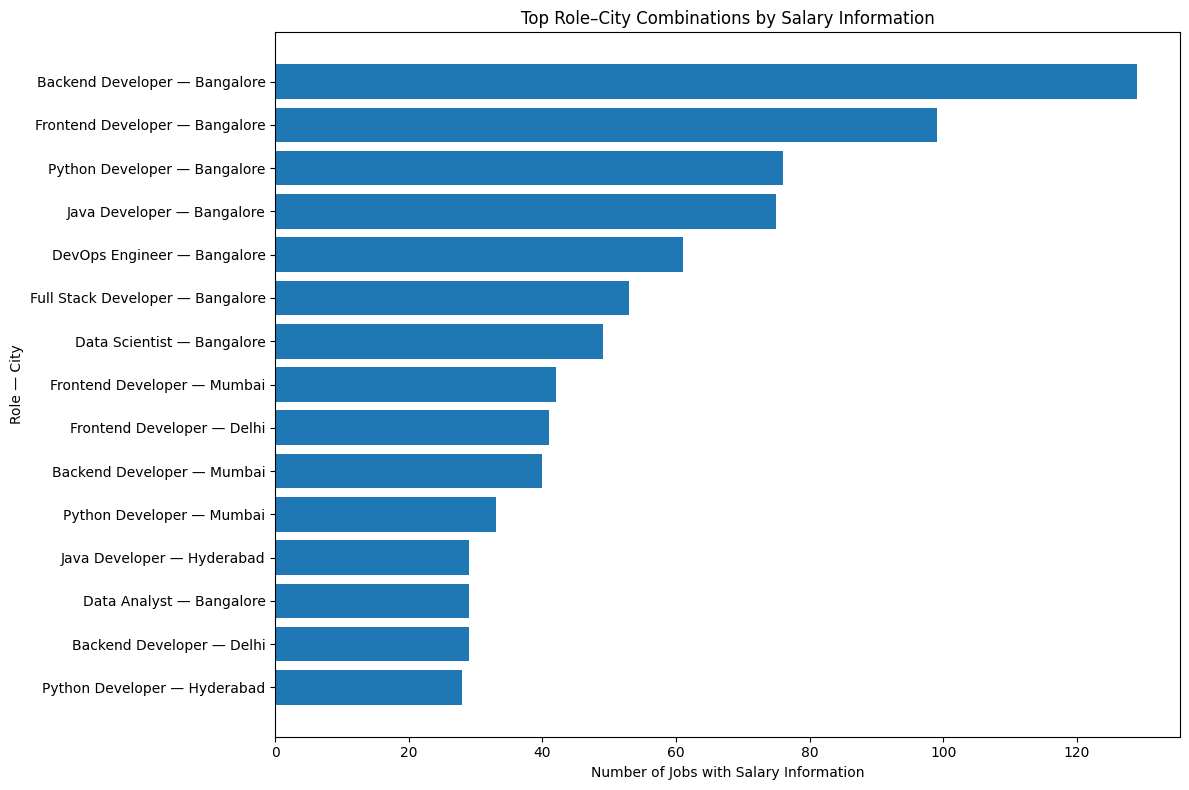

In [88]:
top_role_city = role_city_salary.head(15).copy()
top_role_city['role_city'] = (top_role_city['standard_role'] +' — ' +top_role_city['city'])
top_role_city = top_role_city.sort_values('job_count')
plt.figure(figsize=(12, 8))

plt.barh(top_role_city['role_city'], top_role_city['job_count'])

plt.title('Top Role–City Combinations by Salary Information')
plt.xlabel('Number of Jobs with Salary Information')
plt.ylabel('Role — City')

plt.tight_layout()
plt.show()

In [90]:
role_city_coverage = (df[df['standard_role'].notna() & df['city'].notna() & df['salary_max'].notna()]
    .groupby('standard_role')['city'].nunique()
    .sort_values(ascending=False))
role_city_coverage

standard_role
Full Stack Developer         28
Backend Developer            23
Business Analyst             23
Python Developer             23
Frontend Developer           21
Java Developer               21
Data Analyst                 18
DevOps Engineer              17
Cyber Security               14
Cloud Engineer               13
Data Scientist               12
Software Engineer            12
Machine Learning Engineer     8
Other                         7
Data Engineer                 5
Sales                         2
Name: city, dtype: int64

In [91]:
level_work_salary = (df[df['job_level_clean'].notna() &df['working_model_clean'].notna() &df['salary_max'].notna()]
    .groupby(['job_level_clean', 'working_model_clean'])
    .agg(job_count=('salary_max', 'count'))
    .reset_index()
    .sort_values('job_count', ascending=False))

level_work_salary

,job_level_clean,working_model_clean,job_count
3,Professional - IC,Flexible,54
6,Professional - IC,In Office,12
7,Professional - IC,"In Office, Flexible, Fully Remote",11
0,People Manager,Flexible,5
9,Senior Manager,Flexible,5
5,Professional - IC,Fully Remote,3
2,Professional - IC,Customer Facing Remote,2
8,Senior Director,Flexible,2
1,People Manager,In Office,1
4,Professional - IC,"Flexible, Customer Facing Remote",1


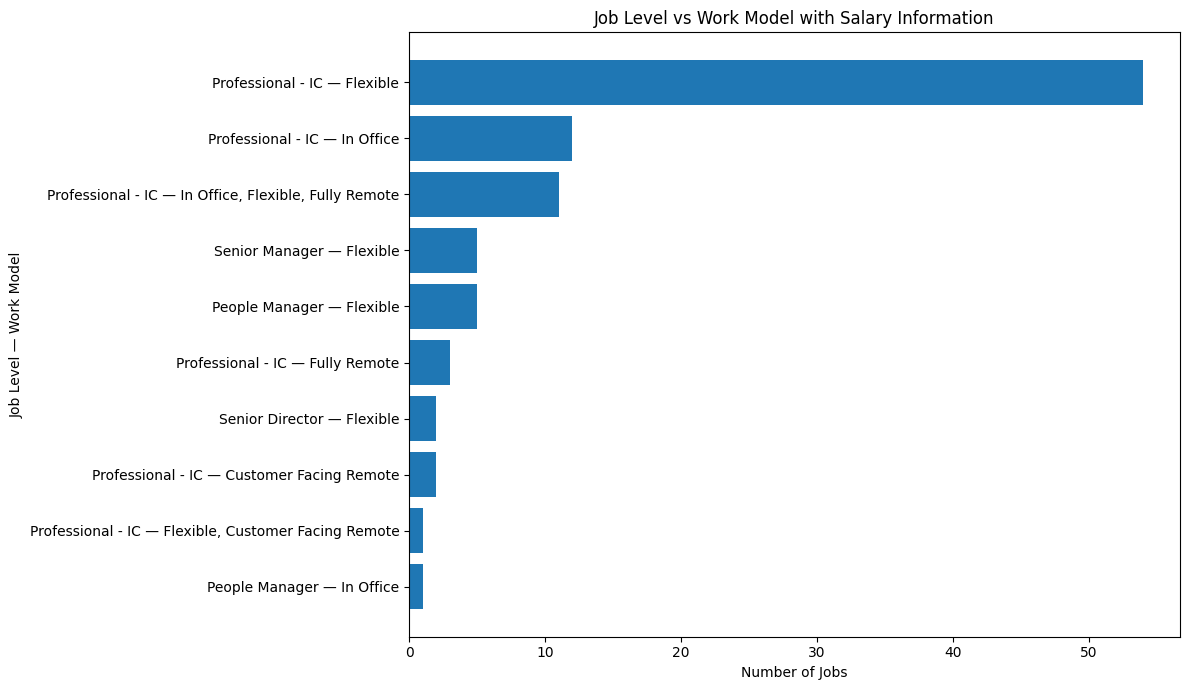

In [92]:
level_work_salary['level_work_model'] = ( level_work_salary['job_level_clean']+ ' — '+ level_work_salary['working_model_clean'])

plot_data = level_work_salary.sort_values('job_count')

plt.figure(figsize=(12, 7))

plt.barh(plot_data['level_work_model'],plot_data['job_count'])

plt.title('Job Level vs Work Model with Salary Information')
plt.xlabel('Number of Jobs')
plt.ylabel('Job Level — Work Model')

plt.tight_layout()
plt.show()

In [93]:
city_role_coverage = (df[df['city'].notna() & df['standard_role'].notna() &df['salary_max'].notna() ]
    .groupby('city')['standard_role']
    .nunique()
    .sort_values(ascending=False))

city_role_coverage.head(15)

city
Pune           15
Mumbai         15
Delhi          15
Bangalore      14
Chennai        14
Hyderabad      13
Noida          12
Ahmedabad      11
Coimbatore     11
Navi Mumbai    10
Kochi          10
Jaipur         10
Gurgaon         9
Indore          8
Vadodara        7
Name: standard_role, dtype: int64

In [94]:
corr_cols = ['salary_min', 'salary_max', 'latitude', 'longitude']
corr_matrix = df[corr_cols].corr()
corr_matrix


,salary_min,salary_max,latitude,longitude
salary_min,1.000000,0.772299,-0.070575,0.054876
salary_max,0.772299,1.000000,-0.124371,0.077277
latitude,-0.070575,-0.124371,1.000000,-0.157399
longitude,0.054876,0.077277,-0.157399,1.000000


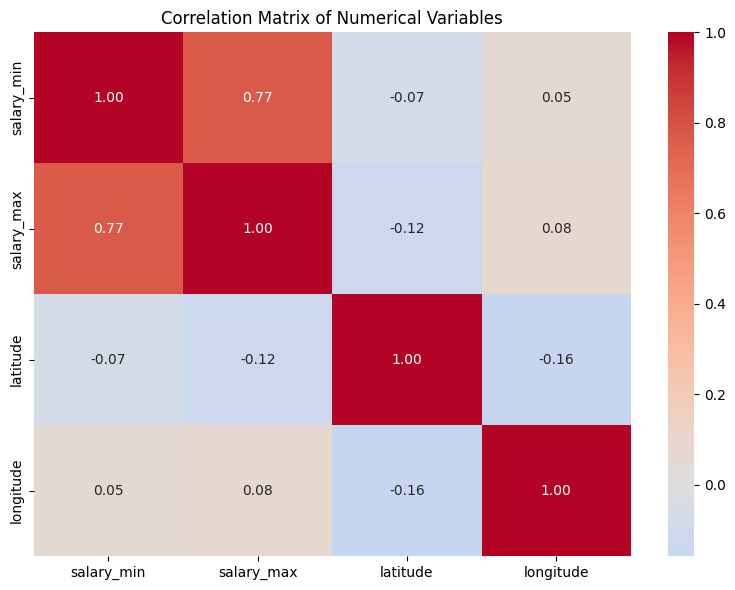

In [95]:
plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix,annot=True,fmt='.2f', cmap='coolwarm',center=0)
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

In [96]:
usd_salary = df.loc[df['salary_currency'].eq('USD'),['salary_min', 'salary_max']].dropna(how='all')
usd_salary.describe()

,salary_min,salary_max
count,468.000000,468.000000
mean,173020.393590,240225.318803
std,56723.955656,82013.302468
min,50000.000000,50000.000000
25%,134200.000000,184750.000000
50%,163700.000000,240000.000000
75%,210925.000000,297750.000000
max,340000.000000,563600.000000


In [97]:
for col in ['salary_min', 'salary_max']:

    Q1 = usd_salary[col].quantile(0.25)
    Q3 = usd_salary[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = usd_salary[(usd_salary[col] < lower_bound) |(usd_salary[col] > upper_bound)]

    print(f"\n{col}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Outlier count:", len(outliers))


salary_min
Q1: 134200.0
Q3: 210925.0
IQR: 76725.0
Lower bound: 19112.5
Upper bound: 326012.5
Outlier count: 6

salary_max
Q1: 184750.0
Q3: 297750.0
IQR: 113000.0
Lower bound: 15250.0
Upper bound: 467250.0
Outlier count: 4


In [98]:
Q1_min = usd_salary['salary_min'].quantile(0.25)
Q3_min = usd_salary['salary_min'].quantile(0.75)
IQR_min = Q3_min - Q1_min
upper_min = Q3_min + 1.5 * IQR_min

Q1_max = usd_salary['salary_max'].quantile(0.25)
Q3_max = usd_salary['salary_max'].quantile(0.75)
IQR_max = Q3_max - Q1_max
upper_max = Q3_max + 1.5 * IQR_max

usd_outliers = df[(df['salary_currency'] == 'USD') &((df['salary_min'] > upper_min) | (df['salary_max'] > upper_max) )
][['title','company_name','salary_currency','salary_min','salary_max','location_clean','job_level_clean']]

usd_outliers.sort_values('salary_max',ascending=False)

,title,company_name,salary_currency,salary_min,salary_max,location_clean,job_level_clean
4976,"Account Executive, Enterprise Platforms (Grower)",Stripe,USD,312000.0,563600.0,"San Francisco, CA; Chicago, IL & New York, NY",NaN
5221,"Manager, Startups Account Executives - Existin...",Stripe,USD,329800.0,494800.0,New York,NaN
4973,"Account Executive, Enterprise - Hunter",Stripe,USD,312000.0,468000.0,"US-San Francisco, US-Chicago, US-New York",NaN
4977,"Account Executive, Enterprise Platforms, Hunter",Stripe,USD,312000.0,468000.0,"New York, NY; San Francisco, CA; Seattle, WA; ...",NaN
6105,"Distinguished Architect, AI",Datadog,USD,330000.0,440000.0,"New York, New York, USA; San Francisco, Califo...",NaN
6985,"Director of Product, Growth/AI",Brex,USD,340000.0,425000.0,"Seattle, Washington, United States",NaN
6986,"Director of Product, Growth/AI",Brex,USD,340000.0,425000.0,"Vancouver, British Columbia, Canada",NaN
6987,"Director of Product, Growth/AI",Brex,USD,340000.0,425000.0,"San Francisco, California, United States",NaN
6988,"Director of Product, Growth/AI",Brex,USD,340000.0,425000.0,"New York, New York, United States",NaN


In [99]:
# IQR analysis identified several high-end USD salary observations as statistical outliers.
# Manual inspection found no clear data-entry or logical errors,
# so these observations were retained as legitimate salary records.

# EDA Conclusions / Business Insights

## 1. Dataset Composition
- Total jobs: 7,269
- Adzuna: 4,964 (68.29%)
- Greenhouse: 2,305 (31.71%)
- The two sources have different field coverage, so some relationships cannot be directly compared.

## 2. Job Role Distribution
The largest standardized Adzuna roles include:
- Frontend Developer — 393
- DevOps Engineer — 393
- Python Developer — 391
- Full Stack Developer — 388
- Java Developer — 384

Note: `standard_role` is Adzuna-specific and should not be interpreted as the role distribution of the entire dataset.

## 3. Geographic Distribution
Top cities by number of jobs:
- Bangalore — 1,335
- Hyderabad — 442
- Mumbai — 422
- Pune — 404
- Chennai — 293

City information is predominantly from Adzuna.

## 4. Salary Information
- Salary minimum available: 2,616 jobs
- Salary maximum available: 2,915 jobs
- Salary currency available: 602 jobs

Because multiple currencies are present, raw salary values should not be directly compared across currencies.

For USD:
- Median minimum salary: $163,700
- Median maximum salary: $240,000

## 5. Work Model
Only 381 jobs contain work-model information.

The most common recorded work arrangement is Flexible, with 294 jobs.

Work-model information is Greenhouse-specific.

## 6. Job Level
`IC - Professional` and `Professional - IC` were standardized into:

`Professional - IC`

The original `job_level` column was preserved, while `job_level_clean` is used for analysis.

## 7. Role and Location
Salary information is concentrated in several role-city combinations.

Examples:
- Backend Developer — Bangalore: 129
- Frontend Developer — Bangalore: 99
- Python Developer — Bangalore: 76

These counts represent jobs with salary information, not total jobs.

## 8. Correlation Analysis
The strongest numerical relationship was:

`salary_min` ↔ `salary_max` = 0.772

This is expected because both variables describe the same salary range.

Latitude and longitude showed weak correlations with salary. However, this does not mean that location has no effect on salary because geographic coordinates are not a direct representation of city-level salary differences.

## 9. Outlier Analysis
The IQR method identified several high-end USD salary observations as statistical outliers.

After manual inspection, no obvious data-quality problems were found, so these observations were retained.

## Overall EDA Conclusion

The dataset contains useful information about job roles, locations, salaries, job levels, and work arrangements. However, the two sources have substantially different field coverage.

Important data-quality considerations:
1. Mixed currencies — raw salaries should not be compared across currencies.
2. Source-specific fields — relationships should only be analyzed where sufficient overlap exists.
3. High missingness — many missing values are structural rather than random.
4. Job-level inconsistency — standardized using `job_level_clean`.
5. Salary outliers — inspected and retained when they appeared legitimate.
6. `standard_role` is Adzuna-specific and should not be generalized to the entire dataset.